# Implementation of LONG SHORT TERM MEMORY(LSTM) RNN using Tensorflow

In [2]:
## import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [12]:
#Data loading, preprocession ans scaling
data=pd.read_csv("monthly_milk_production.csv")
data['Data']=pd.to_datetime(data['Date'])
production=data['Production'].astype(float).values.reshape(-1,1)
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(production)
print(data)

        Date  Production       Data
0    1962-01         589 1962-01-01
1    1962-02         561 1962-02-01
2    1962-03         640 1962-03-01
3    1962-04         656 1962-04-01
4    1962-05         727 1962-05-01
..       ...         ...        ...
163  1975-08         858 1975-08-01
164  1975-09         817 1975-09-01
165  1975-10         827 1975-10-01
166  1975-11         797 1975-11-01
167  1975-12         843 1975-12-01

[168 rows x 3 columns]


In [21]:
#split data into Trainging and testiong
#we split data 80%traing - 20%testing
#use a sliding window of 12 months(1 years)of past data to predict next month pronduct
#split into training and testing and reshaped to match thw LSTM input shape

window_size=12
X= []
y=[]
dates=[]
target_dataset=data.index[window_size]
for i in range (window_size,len(scaled_data)):
    X.append(scaled_data[i - window_size:i, 0])
    y.append(scaled_data[i, 0])
    dates.append(data.index[i])
X=np.array(X)
y=np.array(y)
dates = np.array(dates)
X_train, X_test, y_train, y_test, dates_train, dates_test= train_test_split(X,y,dates, test_size=0.2, shuffle=False)
X_train=X_train.reshape((X_train.shape[0],X_train.shape[1],1))
X_test=X_test.reshape((X_test.shape[0],X_test.shape[1],1))

In [27]:
#Building LSTM
model=Sequential()
model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

#compile the model
model.compile(optimizer='adam',loss='mean_squared_error')

D:\Python 311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
# trainig and evaluateing the model 
his=model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)
prediction=model.predict(X_test)
prediction=scaler.inverse_transform(prediction).flatten()
y_test=scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
rsme=np.sqrt(np.mean(y_test-prediction)**2)
print(f'RSME:{rsme: .2f}')

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0031 - val_loss: 0.0062
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0023 - val_loss: 0.0102
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0028 - val_loss: 0.0095
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0022 - val_loss: 0.0115
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0030 - val_loss: 0.0045
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0034 - val_loss: 0.0165
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0030 - val_loss: 0.0028
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0031 - val_loss: 0.0137
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0032 - val_loss: 0.0080
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0028 - val_loss: 0.0090
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0027 - val_loss: 0.0091
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0021 - val_

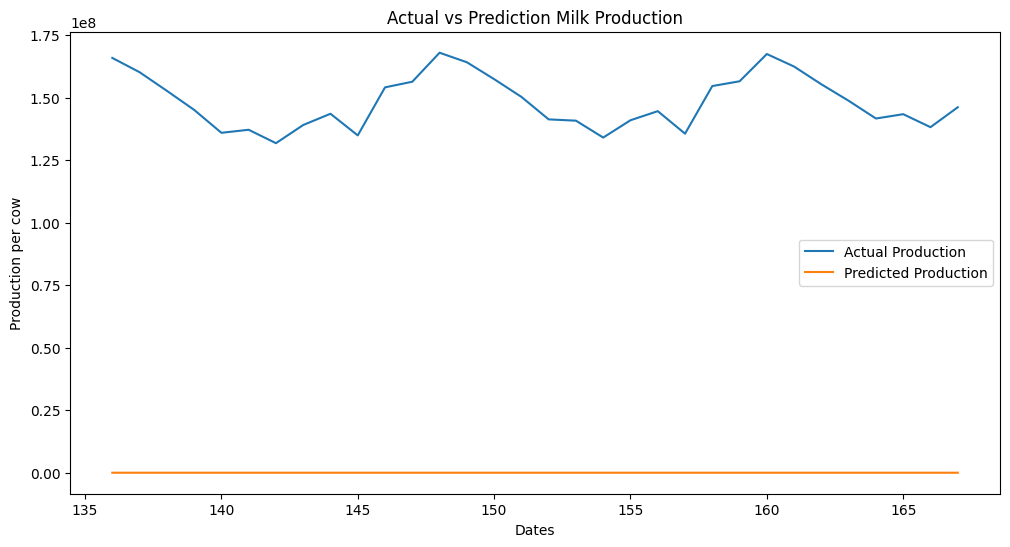

In [31]:
#Visulization the model performance
plt.figure(figsize=(12,6))
plt.plot(dates_test, y_test, label='Actual Production')
plt.plot(dates_test, prediction, label='Predicted Production')
plt.title('Actual vs Prediction Milk Production')
plt.xlabel('Dates')
plt.ylabel('Production per cow')
plt.legend()
plt.show()